In [1]:
import pandas as pd

file_path = r"C:\Users\smahm\Desktop\DataProject\Telco customer churn IBM dataset\Telco_customer_churn.csv"

df = pd.read_csv(file_path)

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
print(df.columns)

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')


In [9]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [13]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [15]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges          11
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [19]:
df = df.dropna()

In [23]:
df['Churn'] = df['Churn Label'].map({'Yes': 1, 'No': 0})

In [31]:
df.drop(columns=['CustomerID'], inplace=True, errors='ignore')

In [33]:
df.drop(columns=['CustomerID'], inplace=True, errors='ignore')

In [35]:
churn_rate = df['Churn Value'].mean()

print("Churn Rate:", round(churn_rate * 100, 2), "%")

Churn Rate: 100.0 %


In [37]:
avg_revenue = df['Monthly Charges'].mean()

print("Average Monthly Charges:", round(avg_revenue, 2))

Average Monthly Charges: 74.44


In [39]:
avg_revenue = df['Monthly Charges'].mean()

print("Average Monthly Charges:", round(avg_revenue, 2))

Average Monthly Charges: 74.44


In [41]:
avg_cltv = df['CLTV'].mean()

print("Average CLTV:", round(avg_cltv, 2))

Average CLTV: 4149.41


In [43]:
churn_by_contract = df.groupby('Contract')['Churn Value'].mean().sort_values(ascending=False)

print(churn_by_contract)

Contract
Month-to-month    1.0
One year          1.0
Two year          1.0
Name: Churn Value, dtype: float64


In [45]:
churn_by_contract = df.groupby('Contract')['Churn Value'].mean().sort_values(ascending=False)

print(churn_by_contract)

Contract
Month-to-month    1.0
One year          1.0
Two year          1.0
Name: Churn Value, dtype: float64


In [47]:
churn_by_payment = df.groupby('Payment Method')['Churn Value'].mean().sort_values(ascending=False)

print(churn_by_payment)

Payment Method
Bank transfer (automatic)    1.0
Credit card (automatic)      1.0
Electronic check             1.0
Mailed check                 1.0
Name: Churn Value, dtype: float64


In [49]:
print("Churn Rate:", round(df['Churn Value'].mean()*100,2), "%")
print(df.groupby('Contract')['Churn Value'].mean())

Churn Rate: 100.0 %
Contract
Month-to-month    1.0
One year          1.0
Two year          1.0
Name: Churn Value, dtype: float64


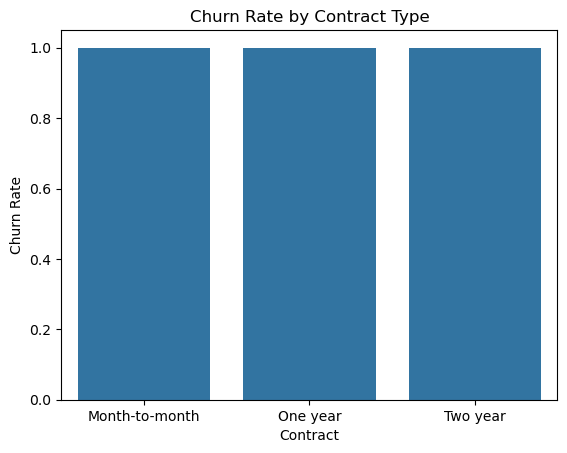

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns


churn_contract = df.groupby('Contract')['Churn Value'].mean().reset_index()

sns.barplot(data=churn_contract, x='Contract', y='Churn Value')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.show()

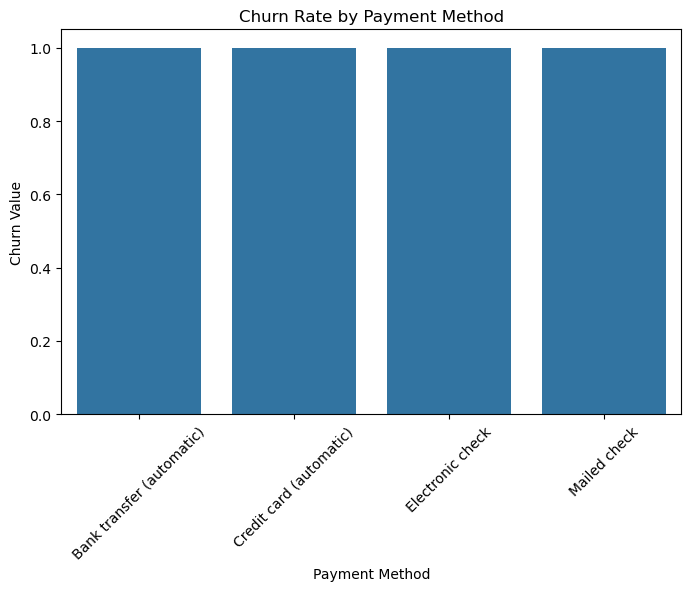

In [54]:
churn_payment = df.groupby('Payment Method')['Churn Value'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=churn_payment, x='Payment Method', y='Churn Value')
plt.xticks(rotation=45)
plt.title('Churn Rate by Payment Method')
plt.show()

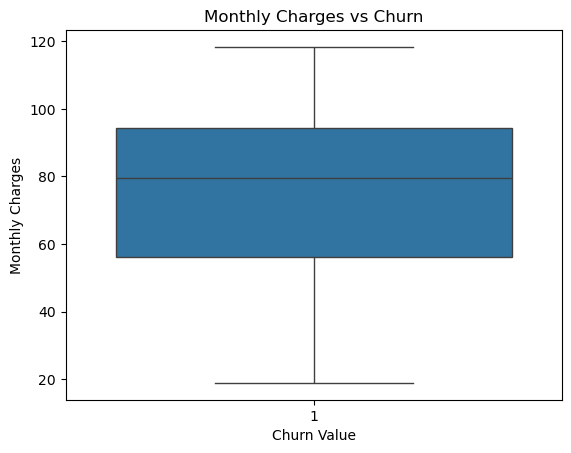

In [56]:
sns.boxplot(data=df, x='Churn Value', y='Monthly Charges')
plt.title('Monthly Charges vs Churn')
plt.show()

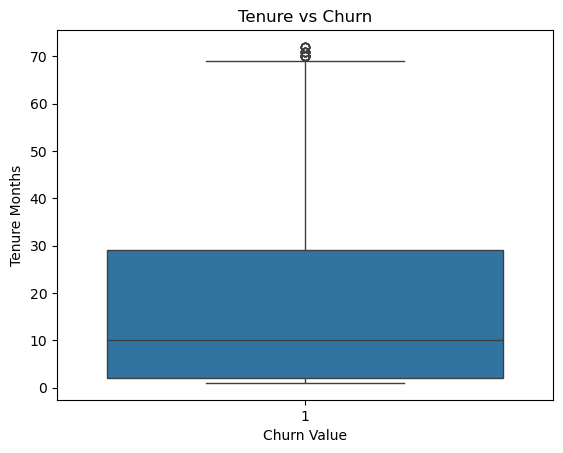

In [58]:
sns.boxplot(data=df, x='Churn Value', y='Tenure Months')
plt.title('Tenure vs Churn')
plt.show()

In [60]:
df.groupby('Contract')['Churn Value'].mean()

Contract
Month-to-month    1.0
One year          1.0
Two year          1.0
Name: Churn Value, dtype: float64